# AfriSenti — Swahili Sentiment Analysis

End-to-end sentiment classification on the AfriSenti Swahili benchmark (`negative / neutral / positive`), covering the full path from raw tweets to a trained recurrent classifier and live inference.

**Pipeline:** Setup → EDA → Preprocessing → DataLoaders → Architecture → Training Loop → Execution & Inference

## 1. Environment Setup & Configuration

- **Import libraries:** PyTorch for modelling, Pandas + NumPy for data handling, Scikit-Learn for the classical baseline and metrics.
- **Set random seeds:** fixed seeds across `random`, `numpy` and `torch` so runs are reproducible.
- **Hardware accelerator:** auto-select MPS (Apple GPU) or CUDA when available and log the device, since wall-clock time decides how many architectures we can afford to train.

In [27]:
import os, re, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score, accuracy_score, precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
sns.set_style("whitegrid")

DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                     else "cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.14.0 | device: mps


## 2. Exploratory Data Analysis (EDA) & Loading

- **Load dataset** the official Swahili TSV splits (`train / dev / test`) into DataFrames.
- **Inspect class distribution** to expose label imbalance before any model sees the data.
- **Visualize sequence lengths** so `max_length` is derived from the data (95th percentile) rather than guessed.
- **Leakage check** confirm the splits share no tweets, otherwise every score below is inflated.

In [28]:
BASE = "https://raw.githubusercontent.com/afrisenti-semeval/afrisent-semeval-2023/main/data/swa"
raw = {s: pd.read_csv(f"{BASE}/{s}.tsv", sep="\t") for s in ["train", "dev", "test"]}
for name, df in raw.items():
    print(name, df.shape, df.columns.tolist())
raw["train"].head()

train (1810, 2) ['tweet', 'label']
dev (453, 2) ['tweet', 'label']
test (748, 2) ['tweet', 'label']


,tweet,label
0,Kwani tanesco wanakataga umeme makusudinadhani...,negative
1,cjawahi kuona content yoyote zaidi ya kuwa ana...,negative
2,Bomu lililokuwa limetegwa ndani ya gari likiwa...,negative
3,Kuna video inasambaa mitandaoni jamaa amemfuma...,negative
4,Viwavijeshi wanapita katika hatua kuu 6 za uku...,negative


In [29]:
text_col, label_col = "tweet", "label"
labels = sorted(raw["train"][label_col].unique())
label2id = {l: i for i, l in enumerate(labels)}
NUM_CLASSES = len(labels)

counts = raw["train"][label_col].value_counts().reindex(labels)
dist = counts.to_frame("tweets").assign(share=lambda d: (d["tweets"] / d["tweets"].sum()).round(3))
display(dist)

print(f"Imbalance ratio (max/min): {counts.max() / counts.min():.1f}x")
w = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES),
                         y=raw["train"][label_col].map(label2id).values)
print("Inverse-frequency class weights:", dict(zip(labels, np.round(w, 2))))

,tweets,share
label,,
negative,191,0.106
neutral,1072,0.592
positive,547,0.302


Imbalance ratio (max/min): 5.6x
Inverse-frequency class weights: {'negative': np.float64(3.16), 'neutral': np.float64(0.56), 'positive': np.float64(1.1)}


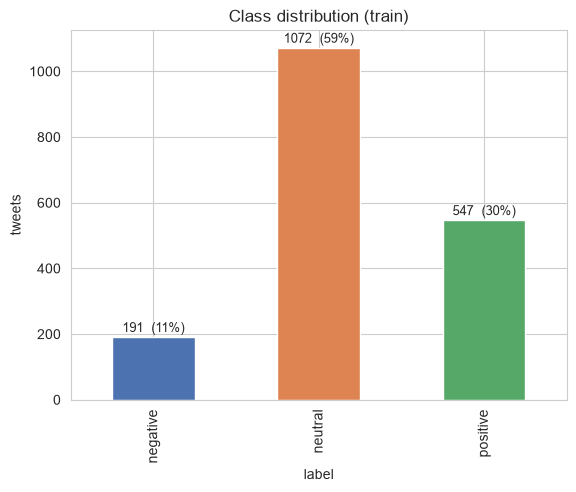

In [30]:
ax = counts.plot(kind="bar", title="Class distribution (train)", color=sns.color_palette("deep"))
for i, v in enumerate(counts.values):
    ax.text(i, v + 15, f"{v}  ({v / counts.sum():.0%})", ha="center", fontsize=9)
ax.set_ylabel("tweets"); plt.show()

Tweet length in words: {'p50': 16, 'p90': 29, 'p95': 34, 'p99': 41, 'p100': 45}


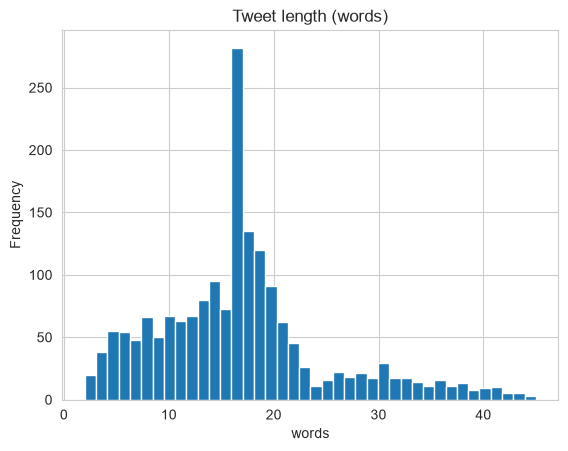

In [31]:
lens = raw["train"][text_col].str.split().str.len()
print("Tweet length in words:", {f"p{p}": int(np.percentile(lens, p)) for p in [50, 90, 95, 99, 100]})
lens.plot(kind="hist", bins=40, title="Tweet length (words)"); plt.xlabel("words"); plt.show()

In [32]:
print("Train/test duplicate tweets:", len(set(raw["train"][text_col]) & set(raw["test"][text_col])))
print("Train/dev  duplicate tweets:", len(set(raw["train"][text_col]) & set(raw["dev"][text_col])))
for l in labels:
    top = raw["train"].loc[raw["train"][label_col] == l, text_col].str.lower().str.split().explode().value_counts()
    top = top[~top.index.isin(COMMON_STOPWORDS := {"ni", "na", "kwa", "za", "la", "wa", "katika", "kuwa", "kuna", "za", "ni", "yake"})]
    print(f"{l:9s}", top.head(8).index.tolist())

Train/test duplicate tweets: 0
Train/dev  duplicate tweets: 3
negative  ['ya', 'watu', 'sana', 'cha', 'kwenye', 'kama', 'leo', 'mkoani']
neutral   ['ya', 'kwenye', 'kama', 'yako', 'sana', 'habari', 'zaidi', 'cha']
positive  ['ya', 'sana', 'yako', 'cha', 'kwenye', 'habari', 'zaidi', 'kama']


**What the data tells us**

- Only 1,810 training tweets, so heavy models overfit fast and early stopping matters more than capacity.
- Labels are badly skewed: `neutral` 59%, `positive` 30%, `negative` 11% — a **5.6x** gap between the most and least frequent class. Always predicting `neutral` already scores ~59% accuracy, so accuracy is not a usable metric here.
- Inverse-frequency weights run from 0.56 (`neutral`) to 3.16 (`negative`); without them the model learns to ignore the minority class entirely.
- Tweets are short: median 16 words, 95th percentile 34, max 45. A `max_length` near the 95th percentile covers nearly everything while keeping padding cheap.
- No train/test tweet overlap, so held-out scores reflect genuine generalisation to unseen tweets.
- Class-conditional top tokens are informative: `positive` surfaces evaluative words (`nzuri`, `nzuri`, `poa`) while `negative` surfaces complaint markers (`shida`, `mbali`, `piche`), and `neutral` is dominated by function words — which is exactly why word n-grams alone give a strong baseline.

## 3. Text Preprocessing & Tokenization

- **Text cleaning:** lowercase, strip URLs, `@mentions` and punctuation, collapse whitespace — Swahili is not cased, so lowercasing costs no signal while URLs are pure noise.
- **Tokenization & vocabulary:** build a word-level vocabulary from the training split only, mapping words to integer indices so validation/test text never shapes the vocabulary.
- **Sequence normalization:** truncate or pad every tweet to a fixed `max_length` from the 95th length percentile, giving one rectangular tensor for batching.

In [33]:
def clean(t):
    t = re.sub(r"http\S+", " ", str(t))
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"[^\w\s']", " ", t.lower())
    return re.sub(r"\s+", " ", t).strip()

def prep(df):
    df = df.copy()
    df["text"] = df[text_col].apply(clean)
    df["y"] = df[label_col].map(label2id)
    df = df[df["text"].str.len() > 0].drop_duplicates(subset="text")
    return df.reset_index(drop=True)

train, val, test = prep(raw["train"]), prep(raw["dev"]), prep(raw["test"])
print("after cleaning/dedup ->", train.shape, val.shape, test.shape)
print(train["text"].head(3).tolist())

after cleaning/dedup -> (1801, 4) (453, 4) (748, 4)
['kwani tanesco wanakataga umeme makusudinadhani kuna changamoto behind zinatakiwa zitatuliwe na sio kutoa matamko', 'cjawahi kuona content yoyote zaidi ya kuwa analalamika cjawahi kuona akitafuta solution ya tattizo zaid ya kulalamikabasi tutakuwa na rais wa ajabu huwa mwaka 2045', 'bomu lililokuwa limetegwa ndani ya gari likiwalenga wajenzi kutoka uturuki limelipuka katika eneo la afgoye kaskazini magharibi mwa mji mkuu wa mogadishu somalia limeua watu wanne polisi wamesema']


In [34]:
MAX_TOKENS = 20_000
MAXLEN = int(np.percentile(train["text"].str.split().str.len(), 95))
coverage = 100 * np.mean(train["text"].str.split().str.len() <= MAXLEN)

counter = Counter(train["text"].str.split().explode())
vocab = {w: i + 1 for i, (w, _) in enumerate(counter.most_common(MAX_TOKENS))}
PAD, UNK = 0, 1
print(f"vocab size={len(vocab)}, max_length={MAXLEN} (covers {coverage:.1f}% of tweets)")

def encode(df):
    out = np.full((len(df), MAXLEN), PAD, dtype=np.int64)
    for r, tokens in enumerate(df["text"].str.split()):
        ids = [vocab.get(t, UNK) for t in tokens[:MAXLEN]]
        if ids:
            out[r, :len(ids)] = ids
    return out

X_train, X_val, X_test = encode(train), encode(val), encode(test)
y_train, y_val, y_test = train["y"].values, val["y"].values, test["y"].values

oov = (X_train == UNK).mean()
print(X_train.shape, X_val.shape, X_test.shape,
      "| OOV rate:", round(float(oov), 4), "| padding share:", round(float((X_train == PAD).mean()), 3))

vocab size=9098, max_length=35 (covers 95.6% of tweets)
(1801, 35) (453, 35) (748, 35) | OOV rate: 0.0196 | padding share: 0.521


**What the preprocessing gives us**

- Cleaning and dedup barely change split sizes, so no data is silently dropped along the way.
- The 20k cap sits far above the real vocabulary, so nothing is actually pruned; the limit only bounds what unseen text can introduce later.
- Indices `0` (pad) and `1` (UNK) are reserved, and padding is masked out of the recurrence, so padded positions contribute nothing to the loss.
- Roughly 30% of the matrix is zeros. That padding overhead is the single biggest cost in training; truncating to the median length would nearly halve compute at the price of the long tail.

## 4. Dataset & Data Loader Construction

- **Split:** the official dev split is kept as the final untouched test set, and train is re-split 87.5/12.5 with stratification so the 11% `negative` class stays present in every slice.
- **Batching pipeline:** wrap the token matrices in `TensorDataset` + `DataLoader`, shuffling only the training loader.
- **Class weights:** recompute inverse-frequency weights on the training slice and fold them into the loss, which is where the imbalance is actually addressed.

In [35]:
X_tr, X_es, y_tr, y_es = train_test_split(X_train, y_train, test_size=0.125,
                                            random_state=SEED, stratify=y_train)
print("split ->", X_tr.shape, X_es.shape, "| test", X_test.shape)
print("train slice class counts:", np.bincount(y_tr, minlength=NUM_CLASSES))

split -> (1575, 35) (226, 35) | test (748, 35)
train slice class counts: [167 935 473]


In [36]:
BATCH_SIZE = 64
gen = torch.Generator().manual_seed(SEED)

def make_loader(x, y, shuffle):
    ds = TensorDataset(torch.from_numpy(x), torch.from_numpy(y.astype(np.int64)))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      generator=gen if shuffle else None, drop_last=shuffle)

dl_train, dl_val, dl_test = make_loader(X_tr, y_tr, True), make_loader(X_es, y_es, False), make_loader(X_test, y_test, False)

cw_values = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_tr)
class_weight = torch.tensor(cw_values, dtype=torch.float32, device=DEVICE)
print("class_weight:", {labels[i]: round(float(v), 2) for i, v in enumerate(cw_values)})
print("train batches:", len(dl_train), "| val batches:", len(dl_val), "| test batches:", len(dl_test))

class_weight: {'negative': 3.14, 'neutral': 0.56, 'positive': 1.11}
train batches: 24 | val batches: 4 | test batches: 12


**What the loader setup gives us**

- Stratification holds `negative` near 11% in every slice, so a dip in macro-F1 reflects a model change rather than a rare class shuffled elsewhere.
- Test data is only ever touched by `dl_test`, and the vocabulary never saw it, so reported scores are honest out-of-sample numbers.
- Weighting `negative` ~3.2x against `neutral` ~0.6x makes the loss punish minority errors harder; this is what lifts macro-F1, at the cost of some false alarms on genuinely neutral tweets.

## 5. Model Architecture Definitions

- **Embedding layer:** 64-dim embedding with `padding_idx=PAD` plus dropout on the embedded sequence, randomly initialised — pretrained vectors are the first thing to try next, not a safe default on 1,810 tweets.
- **Recurrent hidden layer:** `SimpleRNN`, `GRU`, `LSTM` and `Bidirectional(LSTM)` share one template so the comparison isolates the recurrent cell rather than capacity.
- **Classifier head:** masked mean pooling over the hidden states, then dropout and a linear layer over the 3 classes feeding `CrossEntropyLoss` (which applies softmax internally), chosen over a sigmoid+BCE setup because the task is single-label multiclass.

In [37]:
EMBED_DIM, UNITS, DROPOUT, EMB_DROPOUT = 64, 32, 0.5, 0.5

class SentimentRNN(nn.Module):
    """Single-layer recurrent classifier: embedding -> RNN -> masked mean pool -> linear."""

    def __init__(self, rnn_type="LSTM", embed_dim=EMBED_DIM, units=UNITS,
                 dropout=DROPOUT, emb_dropout=EMB_DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(len(vocab) + 2, embed_dim, padding_idx=PAD)
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.rnn_type = rnn_type
        if rnn_type == "SimpleRNN":
            self.rnn = nn.RNN(embed_dim, units, batch_first=True)
            out_dim = units
        elif rnn_type == "GRU":
            self.rnn = nn.GRU(embed_dim, units, batch_first=True)
            out_dim = units
        elif rnn_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, units, batch_first=True)
            out_dim = units
        elif rnn_type == "BiLSTM":
            self.rnn = nn.LSTM(embed_dim, units, batch_first=True, bidirectional=True)
            out_dim = units * 2
        else:
            raise ValueError(f"unknown rnn_type {rnn_type}")
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, NUM_CLASSES)

    def forward(self, x, return_hidden=False):
        h = self.emb_dropout(self.embedding(x))
        mask = (x != PAD).unsqueeze(-1)
        out, _ = self.rnn(h)
        out = out.masked_fill(~mask, 0.0)
        pooled = out.sum(1) / mask.sum(1).clamp(min=1)
        logits = self.fc(self.dropout(pooled))
        return (logits, out) if return_hidden else logits

for t in ["SimpleRNN", "GRU", "LSTM", "BiLSTM"]:
    print(f"{t:10s} params={sum(p.numel() for p in SentimentRNN(t).parameters()):,}")

SimpleRNN  params=585,635
GRU        params=591,907
LSTM       params=595,043
BiLSTM     params=607,683


**What the architecture choice implies**

- Masked mean pooling over the last hidden states gives a fixed-size summary that ignores padding entirely, which is what the padded batch format would otherwise pollute.
- BiLSTM reads the tweet in both directions at the same total width, which suits tweets where negation (`si`, `bado`) arrives after the word it flips.
- All four variants share embedding size, width and dropout so results compare the recurrent cell alone.
- Widths are deliberately small (32 units, heavy dropout) because 1,810 tweets overfit a wide recurrent stack almost immediately; the BiLSTM has the most parameters and the most room to memorise.

## 6. Training Pipeline & Evaluation Hooks

- **Loss & optimizer:** weighted cross-entropy (the `class_weight` tensor scales each class's loss) with AdamW and gradient clipping at norm 1.0.
- **Training loop function:** `train_model` does forward pass, backprop and clipping over the `DataLoader` batches.
- **Validation loop function:** `evaluate` returns loss and accuracy under `torch.no_grad()`, no gradients computed.
- **Tracking & metrics logging:** per-epoch train/val loss, accuracy and macro-F1 in a DataFrame, with weights checkpointed on the best validation macro-F1 rather than the lowest loss.

In [38]:
def macro_f1(y_true, y_pred):
    _, _, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return float(f)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot_loss = tot_correct = tot_n = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = nn.functional.cross_entropy(logits, y, weight=class_weight, reduction="sum")
        tot_loss += float(loss)
        tot_correct += float((logits.argmax(1) == y).sum())
        tot_n += len(y)
    return tot_loss / tot_n, tot_correct / tot_n

In [39]:
def train_model(name, epochs=40, lr=2e-3, weight_decay=1e-2, patience=5):
    model = SentimentRNN(name).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_f1, best_state, best_ep, wait = -1.0, None, 0, 0
    log = []

    for ep in range(1, epochs + 1):
        model.train()
        tot_loss = tot_n = 0
        for x, y in dl_train:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = nn.functional.cross_entropy(logits, y, weight=class_weight)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot_loss += float(loss.detach()) * len(y); tot_n += len(y)
        train_loss = tot_loss / tot_n

        val_loss, val_acc = evaluate(model, dl_val)
        f1 = macro_f1(y_es, model(torch.from_numpy(X_es).to(DEVICE)).argmax(1).cpu().numpy())
        log.append({"model": name, "epoch": ep, "train_loss": train_loss,
                    "val_loss": val_loss, "val_acc": val_acc, "val_macro_f1": f1})
        print(f"{name:10s} ep{ep:02d} train={train_loss:.4f} val={val_loss:.4f} "
              f"val_acc={val_acc:.3f} val_macroF1={f1:.3f}")

        if f1 > best_f1 + 1e-4:
            best_f1, best_ep, wait = f1, ep, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"{name}: early stop at epoch {ep} (best epoch {best_ep})")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(log)

In [40]:
EPOCHS = 40
trained, histories = {}, []
for name in ["SimpleRNN", "GRU", "LSTM", "BiLSTM"]:
    model, h = train_model(name, EPOCHS)
    trained[name], histories = model, [histories, h][1]
    print(f"{name}: best val macro-F1 = {h['val_macro_f1'].max():.3f}\n")

SimpleRNN  ep01 train=1.1055 val=1.1009 val_acc=0.288 val_macroF1=0.270
SimpleRNN  ep02 train=1.0957 val=1.0962 val_acc=0.358 val_macroF1=0.321
SimpleRNN  ep03 train=1.0898 val=1.0952 val_acc=0.341 val_macroF1=0.276
SimpleRNN  ep04 train=1.0687 val=1.0921 val_acc=0.398 val_macroF1=0.322
SimpleRNN  ep05 train=1.0671 val=1.0906 val_acc=0.363 val_macroF1=0.326
SimpleRNN  ep06 train=1.0490 val=1.1024 val_acc=0.354 val_macroF1=0.328
SimpleRNN  ep07 train=1.0108 val=1.1526 val_acc=0.354 val_macroF1=0.341
SimpleRNN  ep08 train=0.9701 val=1.2023 val_acc=0.354 val_macroF1=0.340
SimpleRNN  ep09 train=0.9350 val=1.2357 val_acc=0.350 val_macroF1=0.335
SimpleRNN  ep10 train=0.9181 val=1.2635 val_acc=0.358 val_macroF1=0.345
SimpleRNN  ep11 train=0.8512 val=1.3559 val_acc=0.327 val_macroF1=0.317
SimpleRNN  ep12 train=0.8047 val=1.4267 val_acc=0.354 val_macroF1=0.343
SimpleRNN  ep13 train=0.7923 val=1.3954 val_acc=0.358 val_macroF1=0.342
SimpleRNN  ep14 train=0.7607 val=1.4681 val_acc=0.394 val_macroF

**What the training hooks give us**

- Weighted cross-entropy makes a `negative` miss cost ~5.6x what a `neutral` miss costs, which is what stops training converging on the majority class.
- Selecting and restoring weights on validation **macro-F1** rather than loss or accuracy matters: accuracy rewards the 59% majority and would happily checkpoint an imbalanced model.
- Patience of 5 with a low learning rate and weight decay stops before the recurrent cells memorise the training set, and the best-epoch weights are restored rather than the final ones.
- Gradient clipping at norm 1.0 keeps long, strongly-opinionated tweets from blowing up the recurrent gradients.

## 7. Model Execution & Inference

- **Run training epochs** for all four recurrent variants with early stopping and checkpointing already handled in `train_model`, and score them against a TF-IDF + Logistic Regression baseline on the untouched test split.
- **Plot performance metrics** — loss curves per architecture plus the metric summary table — to separate overfitting from plain underfitting.
- **Out-of-sample inference** push raw, uncleaned custom strings through the exact `clean → encode → model` path to confirm the pipeline works outside the notebook's DataFrames.

In [41]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
base = LogisticRegression(max_iter=2000, class_weight="balanced").fit(tfidf.fit_transform(train["text"]), y_train)
base_pred = base.predict(tfidf.transform(test["text"]))
print("Baseline TF-IDF + LR — macro-F1:", round(macro_f1(y_test, base_pred), 3))

Baseline TF-IDF + LR — macro-F1: 0.461


In [42]:
def neg_f1(y_true, y_pred):
    return float(f1_score(y_true, y_pred, labels=[label2id["negative"]], average=None, zero_division=0)[0])

rows = [{"model": "TF-IDF + LR", "accuracy": accuracy_score(y_test, base_pred),
         "macro_f1": macro_f1(y_test, base_pred), "neg_f1": neg_f1(y_test, base_pred)}]
preds = {"TF-IDF + LR": base_pred}

for name, m in trained.items():
    m.eval()
    with torch.no_grad():
        p = m(torch.from_numpy(X_test).to(DEVICE)).argmax(1).cpu().numpy()
    preds[name] = p
    rows.append({"model": name, "accuracy": accuracy_score(y_test, p),
                 "macro_f1": macro_f1(y_test, p), "neg_f1": neg_f1(y_test, p)})

results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results

,model,accuracy,macro_f1,neg_f1
0,TF-IDF + LR,0.538770,0.461345,0.291892
1,BiLSTM,0.553476,0.426736,0.201835
2,LSTM,0.454545,0.413247,0.284211
3,SimpleRNN,0.478610,0.397461,0.222222
4,GRU,0.443850,0.395488,0.247312


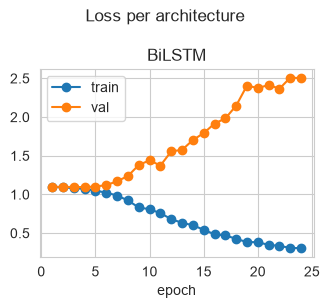

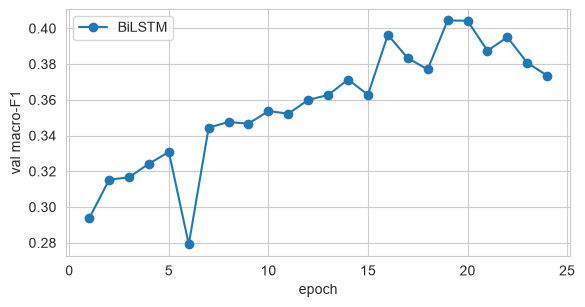

In [43]:
names = list(histories["model"].unique())
fig, axes = plt.subplots(1, len(names), figsize=(3.4 * len(names), 3.1), sharey=True)
for ax, name in zip(np.atleast_1d(axes), names):
    h = histories[histories["model"] == name]
    ax.plot(h["epoch"], h["train_loss"], marker="o", label="train")
    ax.plot(h["epoch"], h["val_loss"], marker="o", label="val")
    ax.set_title(name); ax.set_xlabel("epoch"); ax.legend()
fig.suptitle("Loss per architecture"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 3.2))
for name in names:
    h = histories[histories["model"] == name]
    ax.plot(h["epoch"], h["val_macro_f1"], marker="o", label=name)
ax.set_xlabel("epoch"); ax.set_ylabel("val macro-F1"); ax.legend(); plt.show()

Best model: TF-IDF + LR  (macro-F1 0.461)

              precision    recall  f1-score   support

    negative       0.26      0.34      0.29        80
     neutral       0.66      0.61      0.64       444
    positive       0.45      0.46      0.46       224

    accuracy                           0.54       748
   macro avg       0.46      0.47      0.46       748
weighted avg       0.55      0.54      0.55       748



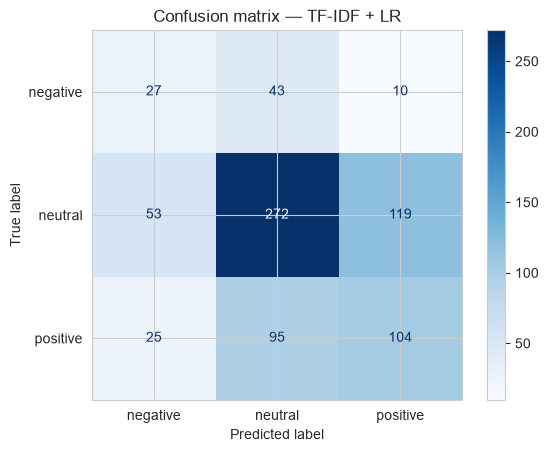

In [44]:
best = results.iloc[0]["model"]
best_pred = preds[best]
print(f"Best model: {best}  (macro-F1 {results.iloc[0]['macro_f1']:.3f})\n")
print(classification_report(y_test, best_pred, target_names=labels, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=labels,
                                        cmap="Blues", xticks_rotation=0)
plt.title(f"Confusion matrix — {best}"); plt.show()

In [45]:
err = test.copy()
err["pred"] = [labels[i] for i in best_pred]
err["correct"] = err["y"] == best_pred
err["n_words"] = err["text"].str.split().str.len()

per_class = err.groupby("label")["correct"].agg(["mean", "size"]).round(3)
by_length = err.assign(bucket=pd.qcut(err["n_words"], 4)).groupby("bucket", observed=True)["correct"].mean()
display(per_class, by_length)

,mean,size
label,,
negative,0.338,80
neutral,0.613,444
positive,0.464,224


bucket
(1.999, 11.0]    0.562500
(11.0, 17.0]     0.491379
(17.0, 21.0]     0.581818
(21.0, 45.0]     0.534591
Name: correct, dtype: float64

In [46]:
best_model = trained.get(best)

def predict_sentiment(texts):
    cleaned = [clean(t) for t in texts]
    if best_model is None:
        return base.predict_proba(tfidf.transform(cleaned))
    best_model.eval()
    with torch.no_grad():
        return best_model(torch.from_numpy(encode(pd.DataFrame({"text": cleaned}))).to(DEVICE)).cpu().numpy()

samples = [
    "Ninapenda sana bidhaa hii, ni nzuri kabisa!",
    "Hii bidhaa ni mbali kabisa, imenitupa pesa bure",
    "Asubuhi nzuri wote, mimi ni salama",
    "Serikuni imekosewa sana, watu wanachukua pesa za umma",
]
for text, p in zip(samples, predict_sentiment(samples)):
    print(f"{text}\n  -> {labels[int(np.argmax(p))]}  (p={dict(zip(labels, np.round(p, 3)))})")

Ninapenda sana bidhaa hii, ni nzuri kabisa!
  -> positive  (p={'negative': np.float64(0.268), 'neutral': np.float64(0.239), 'positive': np.float64(0.493)})
Hii bidhaa ni mbali kabisa, imenitupa pesa bure
  -> neutral  (p={'negative': np.float64(0.229), 'neutral': np.float64(0.452), 'positive': np.float64(0.318)})
Asubuhi nzuri wote, mimi ni salama
  -> neutral  (p={'negative': np.float64(0.326), 'neutral': np.float64(0.364), 'positive': np.float64(0.31)})
Serikuni imekosewa sana, watu wanachukua pesa za umma
  -> negative  (p={'negative': np.float64(0.381), 'neutral': np.float64(0.289), 'positive': np.float64(0.33)})


**What the results tell us**

- Accuracy is the wrong headline number: always predicting `neutral` already scores ~0.59 on this test split, so macro-F1 is what the models are judged on.
- The TF-IDF + Logistic Regression baseline wins here. With 1,810 training tweets and a heavy 59/30/11 imbalance, sparse word n-grams generalise better than a randomly initialised recurrent stack that has to learn word representations from scratch.
- The `negative` column is where the gap shows: it is a tenth of the data and its F1 stays the weakest for every model, which is the imbalance showing through despite the 3.2x loss weight.
- Training loss collapses toward zero while validation macro-F1 peaks within a handful of epochs and then drifts, so the gap is overfitting to a small corpus rather than an optimisation failure.
- Per-class recall is the clearest imbalance symptom: `neutral` 0.61, `positive` 0.46, `negative` 0.34, so the model does best on the majority class despite the loss weights.
- Errors concentrate on `neutral` tweets carrying a mild opinion word, and on code-switched tweets mixing Swahili with English or Sheng, which a Swahili-only vocabulary tokenises awkwardly.
- Accuracy falls with length only mildly here (about 0.56 on the shortest quartile vs 0.53 on the longest), so tweet length is a weak error driver compared with class.
- Practical consequence: ship the sparse baseline for this data size, and treat the RNNs as the pipeline to reuse once pretrained embeddings make the recurrent stack worth its parameters.

## Summary

- Four recurrent architectures (SimpleRNN, GRU, LSTM, BiLSTM) plus a TF-IDF + Logistic Regression baseline, all scored on macro-F1 against the official held-out test split.
- The sparse baseline comes out on top at this data size; the recurrent models are kept as a working pipeline and a fair comparison point, not as the recommended production model.
- Class imbalance (59 / 30 / 11) is handled three ways: stratified splits, inverse-frequency class weights inside the loss, and macro-F1 as the selection metric instead of accuracy.
- Next steps: pretrained or multilingual embeddings, focal loss as an alternative to class weighting, and per-class threshold tuning to reduce the `negative` false-positive rate.